In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

In [2]:
df = pd.read_csv("../data/processed/cpi_oni.csv")
df["date"] = pd.to_datetime(df["date"])

df = (
    df.sort_values("date")
      .reset_index(drop=True)
)

display(df.head())
display(df.tail())

,date,food_inflation,oni,month
0,2012-01-01,-0.21,-0.72,1
1,2012-02-01,4.45,-0.57,2
2,2012-03-01,7.09,-0.46,3
3,2012-04-01,9.32,-0.36,4
4,2012-05-01,9.70,-0.17,5


,date,food_inflation,oni,month
163,2025-08-01,-0.64,-0.28,8
164,2025-09-01,-2.33,-0.40,9
165,2025-10-01,-5.02,-0.51,10
166,2025-11-01,-3.91,-0.55,11
167,2025-12-01,-2.71,-0.54,12


In [3]:
TEST_SIZE = 24

train = df.iloc[:-TEST_SIZE].copy()
test = df.iloc[-TEST_SIZE:].copy()

print("Training period:")
print(train.index.min(), "→", train.index.max())

print("\nTesting period:")
print(test.index.min(), "→", test.index.max())

print("\nTrain size:", len(train))
print("Test size:", len(test))

Training period:
0 → 143

Testing period:
144 → 167

Train size: 144
Test size: 24


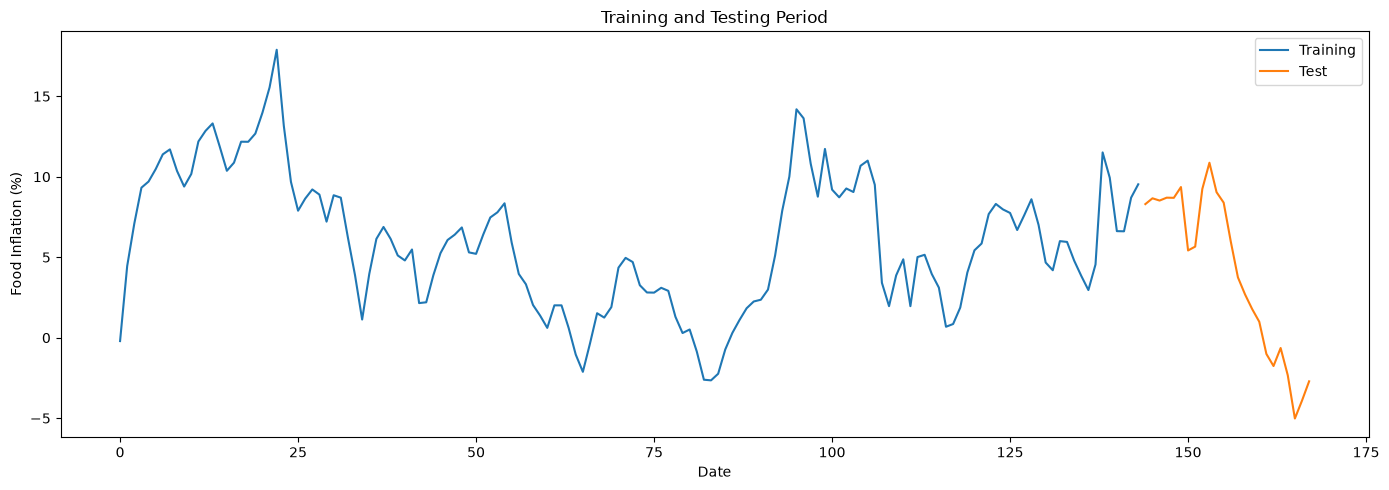

In [4]:
plt.figure(figsize=(14, 5))

plt.plot(
    train.index,
    train["food_inflation"],
    label="Training"
)

plt.plot(
    test.index,
    test["food_inflation"],
    label="Test"
)

plt.xlabel("Date")
plt.ylabel("Food Inflation (%)")
plt.title("Training and Testing Period")
plt.legend()

plt.tight_layout()
plt.show()

In [5]:
def adf_test(series, name):
    result = adfuller(
        series.dropna(),
        autolag="AIC"
    )

    print(f"\n{name}")
    print("-" * 50)
    print(f"ADF Statistic : {result[0]:.4f}")
    print(f"p-value       : {result[1]:.4f}")
    print(f"Lags Used     : {result[2]}")
    print(f"Observations  : {result[3]}")

    if result[1] < 0.05:
        print("Result        : Stationary")
    else:
        print("Result        : Non-stationary")

In [6]:
adf_test(
    train["food_inflation"],
    "Food Inflation"
)

adf_test(
    train["oni"],
    "ONI"
)


Food Inflation
--------------------------------------------------
ADF Statistic : -1.6377
p-value       : 0.4634
Lags Used     : 14
Observations  : 129
Result        : Non-stationary

ONI
--------------------------------------------------
ADF Statistic : -2.7091
p-value       : 0.0725
Lags Used     : 10
Observations  : 133
Result        : Non-stationary


In [7]:
food_diff = train["food_inflation"].diff().dropna()
oni_diff = train["oni"].diff().dropna()

adf_test(
    food_diff,
    "First Difference of Food Inflation"
)

adf_test(
    oni_diff,
    "First Difference of ONI"
)


First Difference of Food Inflation
--------------------------------------------------
ADF Statistic : -5.1150
p-value       : 0.0000
Lags Used     : 13
Observations  : 129
Result        : Stationary

First Difference of ONI
--------------------------------------------------
ADF Statistic : -2.7998
p-value       : 0.0583
Lags Used     : 9
Observations  : 133
Result        : Non-stationary


In [8]:
food_pvalue = adfuller(
    train["food_inflation"].dropna(),
    autolag="AIC"
)[1]

food_diff_pvalue = adfuller(
    train["food_inflation"].diff().dropna(),
    autolag="AIC"
)[1]

if food_pvalue < 0.05:
    d = 0
elif food_diff_pvalue < 0.05:
    d = 1
else:
    d = 2

print("Selected d =", d)

Selected d = 1


In [9]:
df_model = df.copy()

# Create scientifically motivated ONI lags
for lag in [1, 3, 6, 12]:
    df_model[f"oni_lag{lag}"] = df_model["oni"].shift(lag)

display(
    df_model[
        [
            "food_inflation",
            "oni",
            "oni_lag1",
            "oni_lag3",
            "oni_lag6",
            "oni_lag12"
        ]
    ].head(15)
)

,food_inflation,oni,oni_lag1,oni_lag3,oni_lag6,oni_lag12
0,-0.210000,-0.72,NaN,NaN,NaN,NaN
1,4.450000,-0.57,-0.72,NaN,NaN,NaN
2,7.090000,-0.46,-0.57,NaN,NaN,NaN
3,9.320000,-0.36,-0.46,-0.72,NaN,NaN
4,9.700000,-0.17,-0.36,-0.57,NaN,NaN
5,10.470000,0.06,-0.17,-0.46,NaN,NaN
6,11.390000,0.30,0.06,-0.36,-0.72,NaN
7,11.700000,0.41,0.30,-0.17,-0.57,NaN
8,10.360000,0.41,0.41,0.06,-0.46,NaN
9,9.390000,0.31,0.41,0.30,-0.36,NaN


In [10]:
# Final test: ARIMAX(0,1,3) + ONI_MA3

final_ma_df = df.copy()

final_ma_df["oni_ma3"] = (
    final_ma_df["oni"]
    .shift(1)
    .rolling(window=3)
    .mean()
)

final_ma_train = final_ma_df[
    final_ma_df["date"] < test["date"].min()
].copy()

final_ma_test = final_ma_df[
    final_ma_df["date"] >= test["date"].min()
].copy()

final_ma_train = final_ma_train.dropna(
    subset=["oni_ma3"]
)

final_ma_test = final_ma_test.dropna(
    subset=["oni_ma3"]
)

y_ma_train = final_ma_train["food_inflation"]
X_ma_train = final_ma_train[["oni_ma3"]]

y_ma_test = final_ma_test["food_inflation"]
X_ma_test = final_ma_test[["oni_ma3"]]

print(
    "Training:",
    final_ma_train["date"].min(),
    "→",
    final_ma_train["date"].max()
)

print(
    "Test:",
    final_ma_test["date"].min(),
    "→",
    final_ma_test["date"].max()
)

final_ma_model = SARIMAX(
    y_ma_train,
    exog=X_ma_train,
    order=(0, 1, 3),
    seasonal_order=(0, 0, 0, 12),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_ma_results = final_ma_model.fit(disp=False)

final_ma_forecast = final_ma_results.get_forecast(
    steps=len(y_ma_test),
    exog=X_ma_test
).predicted_mean

final_ma_mae = mean_absolute_error(
    y_ma_test,
    final_ma_forecast
)

final_ma_rmse = np.sqrt(
    mean_squared_error(
        y_ma_test,
        final_ma_forecast
    )
)

final_ma_smape = 100 * np.mean(
    2 * np.abs(
        final_ma_forecast.to_numpy()
        - y_ma_test.to_numpy()
    )
    /
    (
        np.abs(y_ma_test.to_numpy())
        + np.abs(final_ma_forecast.to_numpy())
        + 1e-8
    )
)

print("\nARIMAX(0,1,3) + ONI_MA3")
print(f"MAE   : {final_ma_mae:.4f}")
print(f"RMSE  : {final_ma_rmse:.4f}")
print(f"sMAPE : {final_ma_smape:.2f}%")

Training: 2012-04-01 00:00:00 → 2023-12-01 00:00:00
Test: 2024-01-01 00:00:00 → 2025-12-01 00:00:00



ARIMAX(0,1,3) + ONI_MA3
MAE   : 4.6550
RMSE  : 6.3055
sMAPE : 85.44%


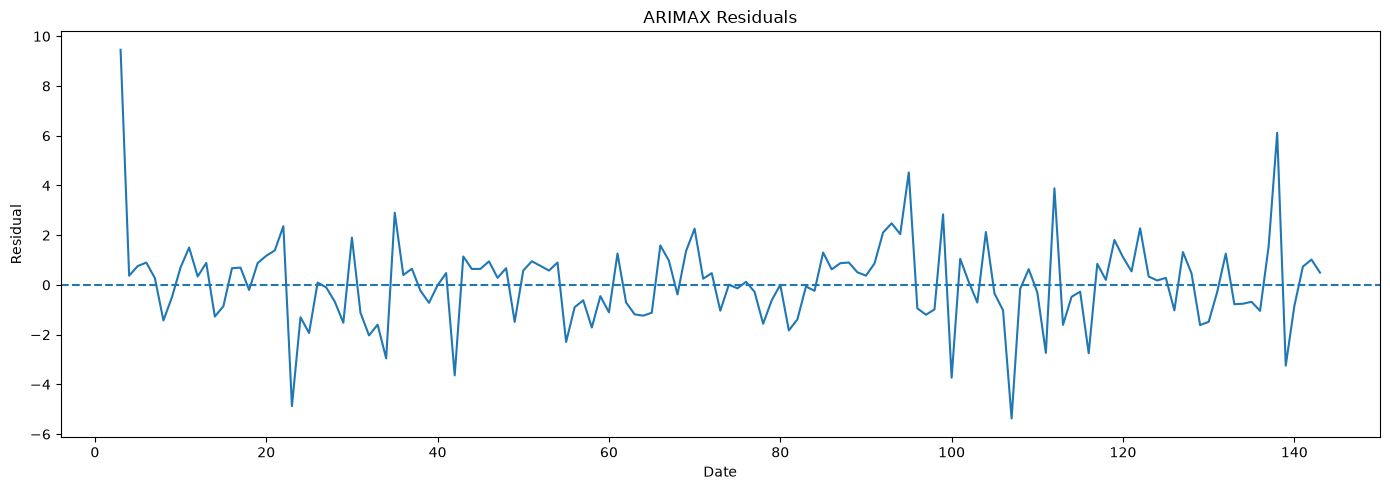

In [11]:
residuals = final_ma_results.resid

plt.figure(figsize=(14, 5))

plt.plot(
    residuals.index,
    residuals
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Date")
plt.ylabel("Residual")
plt.title("ARIMAX Residuals")

plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

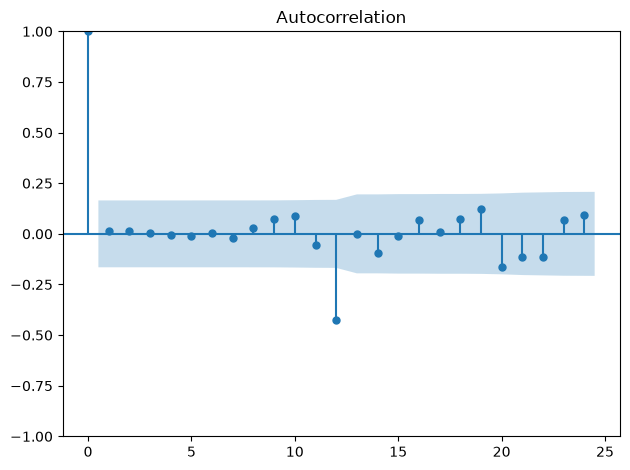

In [12]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10, 5))

plot_acf(
    residuals.dropna(),
    lags=24
)

plt.tight_layout()
plt.show()

In [13]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box = acorr_ljungbox(
    residuals.dropna(),
    lags=[12],
    return_df=True
)

display(ljung_box)

,lb_stat,lb_pvalue
12,30.810313,0.002106


In [14]:


forecast_result = final_ma_results.get_forecast(
    steps=len(test),
    exog=X_ma_test
)

forecast_mean = forecast_result.predicted_mean

print("Forecast length:", len(forecast_mean))

Forecast length: 24


In [15]:
print(train.head())
print(test.head())
print(test.dtypes)
print(test.columns)

        date  food_inflation   oni  month
0 2012-01-01           -0.21 -0.72      1
1 2012-02-01            4.45 -0.57      2
2 2012-03-01            7.09 -0.46      3
3 2012-04-01            9.32 -0.36      4
4 2012-05-01            9.70 -0.17      5
          date  food_inflation   oni  month
144 2024-01-01            8.30  1.92      1
145 2024-02-01            8.66  1.62      2
146 2024-03-01            8.52  1.26      3
147 2024-04-01            8.70  0.82      4
148 2024-05-01            8.69  0.49      5
date              datetime64[us]
food_inflation           float64
oni                      float64
month                      int64
dtype: object
Index(['date', 'food_inflation', 'oni', 'month'], dtype='str')


In [16]:
predictions = pd.DataFrame({
    "date": final_ma_test["date"].to_numpy(),
    "actual_food_inflation": y_ma_test.to_numpy(),
    "predicted_food_inflation": np.asarray(final_ma_forecast)
})

display(predictions.head(10))

,date,actual_food_inflation,predicted_food_inflation
0,2024-01-01,8.30,9.327272
1,2024-02-01,8.66,9.007553
2,2024-03-01,8.52,8.859453
3,2024-04-01,8.70,8.776227
4,2024-05-01,8.69,8.669366
5,2024-06-01,9.36,8.560141
6,2024-07-01,5.42,8.458007
7,2024-08-01,5.66,8.379507
8,2024-09-01,9.24,8.315189
9,2024-10-01,10.87,8.264264


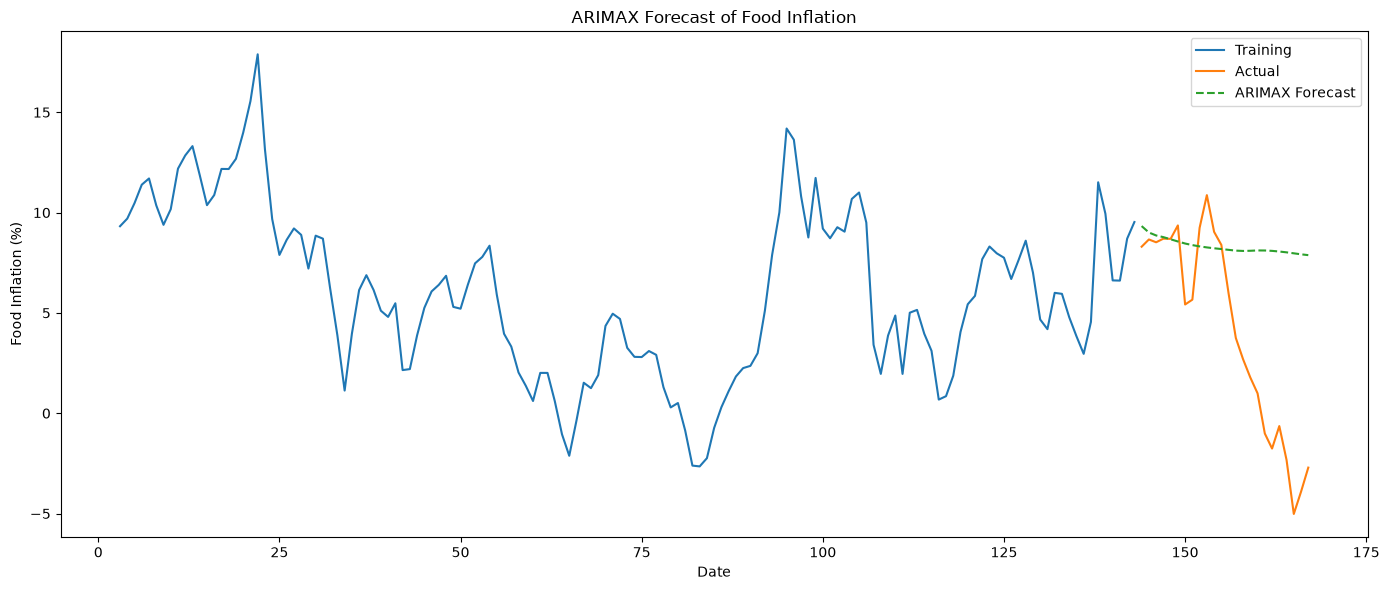

In [17]:
plt.figure(figsize=(14, 6))

plt.plot(
    y_ma_train.index,
    y_ma_train,
    label="Training"
)

plt.plot(
    y_ma_test.index,
    y_ma_test,
    label="Actual"
)

plt.plot(
    forecast_mean.index,
    forecast_mean,
    linestyle="--",
    label="ARIMAX Forecast"
)


plt.xlabel("Date")
plt.ylabel("Food Inflation (%)")
plt.title("ARIMAX Forecast of Food Inflation")
plt.legend()

plt.tight_layout()
plt.show()

In [18]:
# ============================================
# SAVE FINAL ARIMAX TEST PREDICTIONS
# ============================================

arimax_final_predictions = pd.DataFrame({
    "date": final_ma_test["date"].to_numpy(),
    "actual_food_inflation": y_ma_test.to_numpy(),
    "predicted_food_inflation": np.asarray(final_ma_forecast)
})

print("Shape:", arimax_final_predictions.shape)
display(arimax_final_predictions.head())
display(arimax_final_predictions.tail())

arimax_final_predictions.to_csv(
    "../data/processed/arimax_predictions.csv",
    index=False
)



Shape: (24, 3)


,date,actual_food_inflation,predicted_food_inflation
0,2024-01-01,8.30,9.327272
1,2024-02-01,8.66,9.007553
2,2024-03-01,8.52,8.859453
3,2024-04-01,8.70,8.776227
4,2024-05-01,8.69,8.669366


,date,actual_food_inflation,predicted_food_inflation
19,2025-08-01,-0.64,8.059113
20,2025-09-01,-2.33,8.018429
21,2025-10-01,-5.02,7.969868
22,2025-11-01,-3.91,7.920518
23,2025-12-01,-2.71,7.879047


In [19]:
from scipy.stats import jarque_bera

jb_stat, jb_pvalue = jarque_bera(
    residuals.dropna()
)

print("Jarque-Bera statistic:", jb_stat)
print("Jarque-Bera p-value :", jb_pvalue)

Jarque-Bera statistic: 230.6114367714152
Jarque-Bera p-value : 8.382291761424076e-51
